In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import spectral
import numpy as np

### Info

Sensor type in the Kitchen dataset: SPECIM IQ

Serial number: 190-1000103

Sensor ID: XSB32570209

Firmware: 2019.05.31.1

This Python notebook has been made to demonstrate and aid the usage of hyper spectral (HS) images with Python. The HS material used in this notebook is the Kitchen dataset: it contains HS images of 23 light-colored substances found in a regular kitchen. The images have been captured with 204 spectral bands and have 512x512 px spatial resolution and 7 nm spectral resolution. The images also have ground truth annotations available. There are also 4 images with multiple different substances.

<br>

Below is an example PNG image of a petridish filled with basmati rice on a black background.

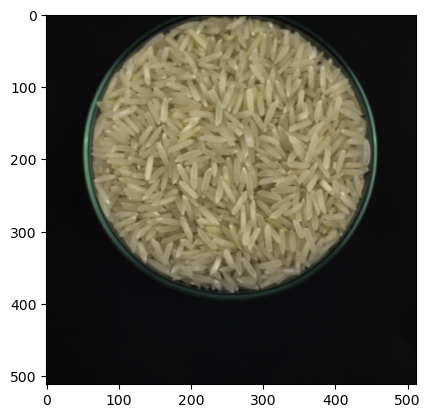

In [3]:
img = img.imread('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/040.png')
plt.imshow(img)

### Preprocessing

The images need to be preprocessed before they can be reliably used in research. A simple way of preprocessing is cropping the photo to reduce the amount of unnecessary data. There might also be unintentional noise or offset in the data. This is why the capture folder contains images labelled `WHITEREF_nr` and `DARKREF_nr`. These images are used to remove the possible noise or offset as thoroughly as possible, and to get an idea of the sensor's sensitivity to light.

<br>

Below are some example images of the bands of the spectral cube.

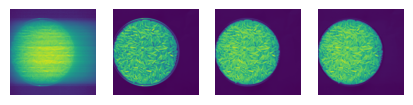

In [12]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 4

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()

The noise cancellation and offset removal happens by subtracting the dark reference from the raw data and then dividing the result with the raw data subtracted from the white reference.

# Mitkä on käytetyt spektrit?